In [1]:
from astropy.io import ascii, fits
from astropy.table import Table
from run_prospector_new2 import *
from prospect.io import read_results as pread
import pandas as pd
import corner
import matplotlib.pyplot as plt
import numpy as np
import plotfancy as pf
from matplotlib.ticker import MaxNLocator
from tqdm import tqdm
pf.housestyle_rcparams()

True

In [2]:
TAB = Table(ascii.read('sedrun.csv'))
ROW = TAB[0]
FILE = 'out/224d52m16pt41356234s-18d10m42pt80767292sresults_3.h5'
model = build_model(ROW)
model_params = model.theta_labels()
# from run_prosp_nonparaSFH import build_model, build_sps
results, observations_dict, _ = pread.results_from(FILE)
sps = pread.get_sps(results)
weights = results.get('weights',None) #likelihood values

building model


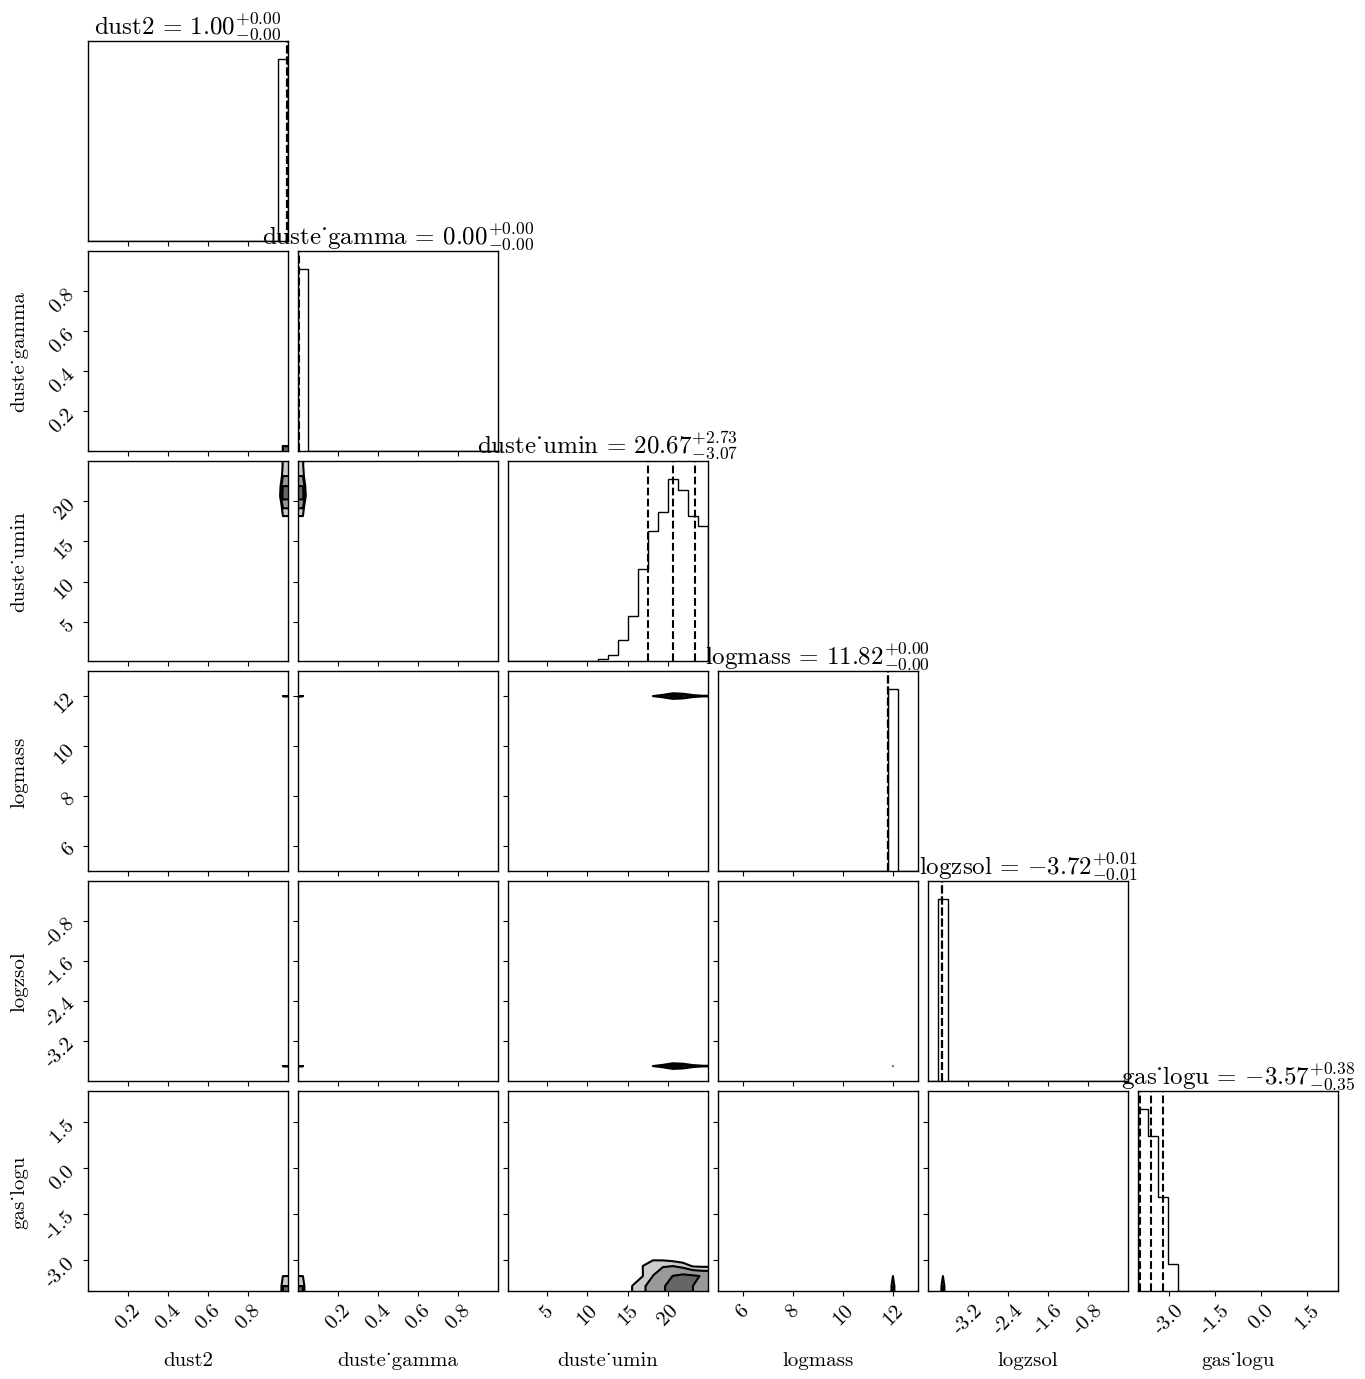

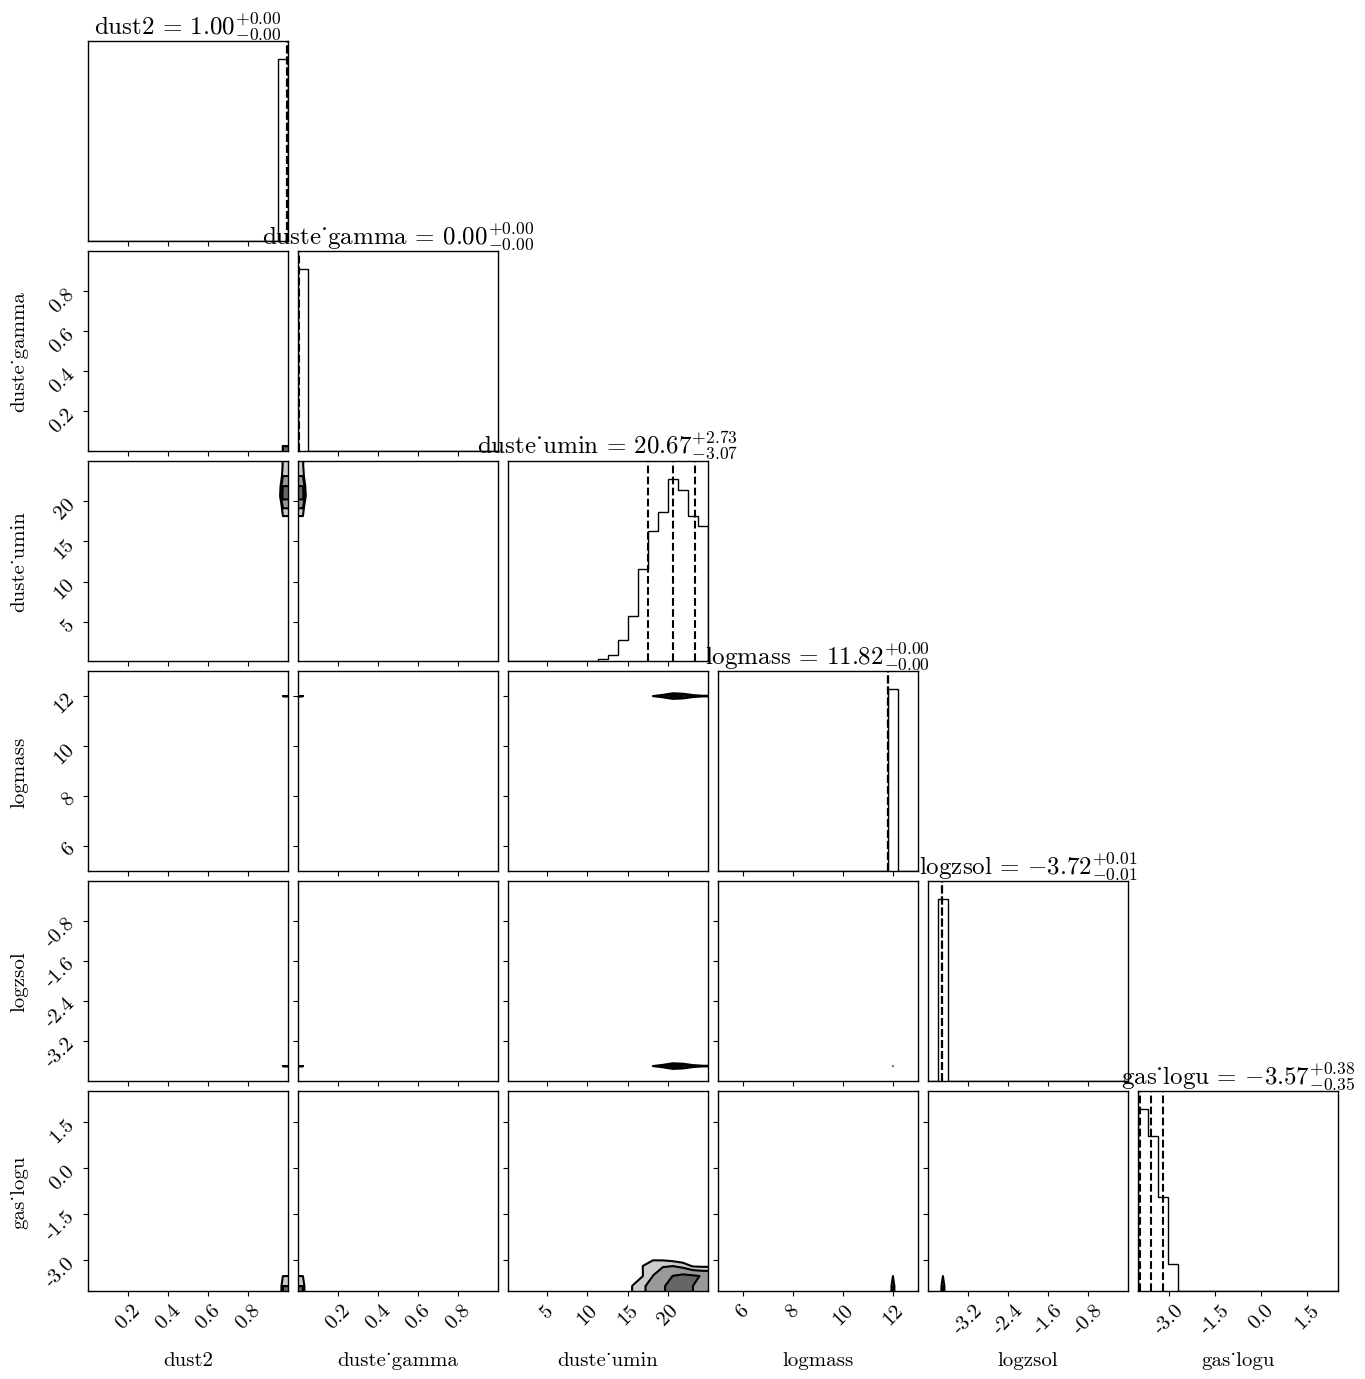

In [3]:
pread.subcorner(results, showpars=['dust2','duste_gamma','duste_umin','logmass','logzsol','gas_logu'])

In [4]:
def get_stellar_mass(res, obs, model, sps, percentiles=[16, 50, 84], nsample=5000):
    
    theta_labels = res.get('theta_labels', model.theta_labels())
    chain = res['chain']
    weights = res.get('weights', None)
    nsamples = chain.shape[0]

    # subsample using dynesty weights so the subset is still representative
    if nsamples > nsample:
        weights_norm = weights / weights.sum()
        idx = np.random.choice(nsamples, size=nsample, replace=False, p=weights_norm)
        chain = chain[idx]
        weights = None  # already accounted for in the sampling, use uniform after
        nsamples = nsample

    logmass_idx = theta_labels.index('logmass')
    stellar_masses = np.zeros(nsamples)

    for ii in tqdm(range(nsamples)):
        theta = chain[ii]
        spec, phot, mfrac = model.predict(theta, obs=obs, sps=sps)
        logmass = chain[ii, logmass_idx]
        stellar_masses[ii] = (10**logmass) * mfrac
        
        # if ii % 500 == 0:
        #     print(f'  {ii}/{nsamples} samples done')

    def weighted_quantile(values, quantiles, weights):
        sorter = np.argsort(values)
        values = values[sorter]
        weights = weights[sorter]
        cumsum = np.cumsum(weights)
        cumsum /= cumsum[-1]
        return np.interp(quantiles, cumsum, values)

    if weights is not None:
        mass_percentiles = weighted_quantile(
            stellar_masses, np.array(percentiles)/100., weights
        )
    else:
        mass_percentiles = np.percentile(stellar_masses, percentiles)

    return stellar_masses, mass_percentiles


In [5]:

stellar_masses, mass_percentiles = get_stellar_mass(results, observations_dict, model, sps=sps)

100%|██████████| 5000/5000 [01:11<00:00, 69.95it/s]


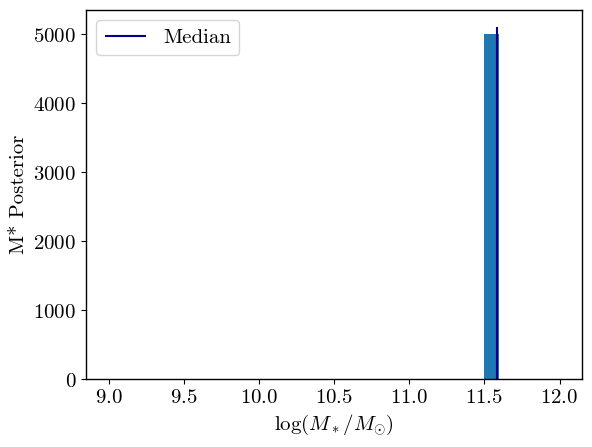

In [6]:
import matplotlib.pyplot as plt
n = plt.hist(np.log10(stellar_masses), range=(9, 12), bins=30)
plt.vlines(np.median(np.log10(stellar_masses)), ymin=0, ymax=np.max(n[0])+100, color='darkblue', label='Median')
plt.ylabel('M* Posterior')
plt.xlabel('$\log(M_* / M_{\odot})$')
plt.legend()

In [7]:
# from prospect.models import transforms
# def get_sfr(res, mod):
#     agebins = mod.params['agebins']
#     thetas = mod.theta_labels()                                                                                                                                           
#     agebins_yrs = 10**agebins.T
#     dt = agebins_yrs[1, :] - agebins_yrs[0, :]
#     zfrac_idx = [i for i, s in enumerate(thetas) if 'z_fraction' in s]
#     zfrac_chain = res['chain'][:,zfrac_idx[0]:zfrac_idx[-1]+1]
    
#     total_mass_chain = res['chain'][:,thetas.index('logmass')]
#     sfr_chain = []
#     weights = results.get('weights',None) #likelihood values
#     idx = np.argsort(weights)[-5000:]
#     for i in idx:
#         #this is the important part of this function -- it takes the proxy model parameters we sampled
#         # and transforms them into the masses formed in each timebin
#         # from there, we just divide these masses by the time in each bin to get the SFR in each bin
#         masses_chain = transforms.zfrac_to_masses(10**total_mass_chain[i], zfrac_chain[i], agebins)
#         sfr = masses_chain / dt                                                                                                                                  
#         sfr_chain.append(sfr[0])                                                                                                                                                
#     return sfr_chain



In [8]:
def get_sfr(res, model, agebins=None, percentiles=[16, 50, 84]):
    """
    Compute the SFR posterior from prospector results.

    Parameters
    ----------
    res : dict
        The results dictionary from prospect (loaded via reader.results_from).
    model : SedModel
        The prospector model object.
    agebins : np.ndarray, optional
        Shape (nbin, 2) array of log(yr) age bin edges.
        If None, pulled from model_params.
    percentiles : list
        Percentiles to return for summary statistics.

    Returns
    -------
    sfr_samples : np.ndarray, shape (nsamples, nbin)
        SFR in Msun/yr for each posterior sample and age bin.
    sfr_percentiles : np.ndarray, shape (len(percentiles), nbin)
        Requested percentiles of the SFR in each bin.
    bin_centers : np.ndarray, shape (nbin,)
        Central lookback time of each bin in Gyr (for plotting).
    agebins : np.ndarray, shape (nbin, 2)
        The age bin edges in log(yr) used.
    """
    import numpy as np

    # --- 1. Pull posterior samples ---
    theta_labels = res.get('theta_labels', model.theta_labels())
    chain = res['chain']                     # (nsamples, nparams)
    weights = res.get('weights', None)

    # --- 2. Recover agebins ---
    if agebins is None:
        parnames = [p['name'] for p in model.config_list]
        agebins = model.config_list[parnames.index('agebins')]['init']
    agebins = np.atleast_2d(agebins)
    nbin = agebins.shape[0]

    # Time spent in each bin, in years
    dt = np.diff(10**agebins, axis=-1)[:, 0]   # (nbin,) [yr]

    # --- 3. Find parameter indices in the chain ---
    logmass_idx = theta_labels.index('logmass')

    # Handle both 'logsfr_ratios' (single vector column) and
    # 'logsfr_ratios_0', 'logsfr_ratios_1', ... (expanded columns)
    sfr_ratio_idxs = [i for i, l in enumerate(theta_labels)
                      if l == 'logsfr_ratios' or l.startswith('logsfr_ratios_')]

    if len(sfr_ratio_idxs) == 1:
        # Stored as a single vector column — already a (nbin-1,) array
        idx = sfr_ratio_idxs[0]
        get_logsfr_ratios = lambda row: row[idx]
    else:
        assert len(sfr_ratio_idxs) == nbin - 1, (
            f"Expected {nbin-1} logsfr_ratio columns, found {len(sfr_ratio_idxs)}"
        )
        get_logsfr_ratios = lambda row: row[sfr_ratio_idxs]

    # --- 4. Reconstruct masses (and SFRs) for every sample ---
    nsamples = chain.shape[0]
    sfr_samples = np.zeros((nsamples, nbin))

    for ii in range(nsamples):
        logmass       = chain[ii, logmass_idx]
        logsfr_ratios = get_logsfr_ratios(chain[ii])

        masses = logsfr_ratios_to_masses(
            logmass=logmass,
            logsfr_ratios=logsfr_ratios,
            agebins=agebins,
        )
        sfr_samples[ii] = masses / dt

    # --- 5. Summary percentiles (weighted if dynesty) ---
    if weights is not None:
        # weighted percentile via cumulative weight sorting
        def weighted_quantile(values, quantiles, weights):
            sorter = np.argsort(values)
            values = values[sorter]
            weights = weights[sorter]
            cumsum = np.cumsum(weights)
            cumsum /= cumsum[-1]
            return np.interp(quantiles, cumsum, values)

        sfr_percentiles = np.array([
            weighted_quantile(sfr_samples[:, bb], np.array(percentiles)/100., weights)
            for bb in range(nbin)
        ]).T
    else:
        sfr_percentiles = np.percentile(sfr_samples, percentiles, axis=0)

    # --- 6. Bin-centre lookback times in Gyr ---
    bin_centers = 10 ** (0.5 * (agebins[:, 0] + agebins[:, 1])) / 1e9  # Gyr

    return sfr_samples, sfr_percentiles, bin_centers, agebins

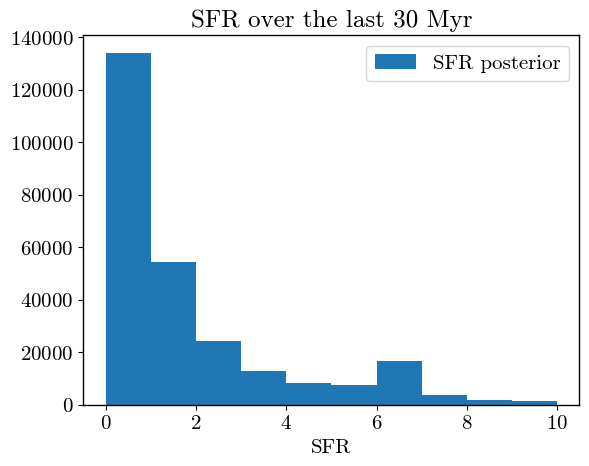

In [9]:
#now plot model SFR histogram
model_sfr,_,_,_ = get_sfr(results, model)
n, _, _, = plt.hist(model_sfr.flatten(), range=(0,10), label='SFR posterior')
plt.title('SFR over the last 30 Myr')
plt.xlabel('SFR')
plt.legend()

agebins shape: (8, 2)


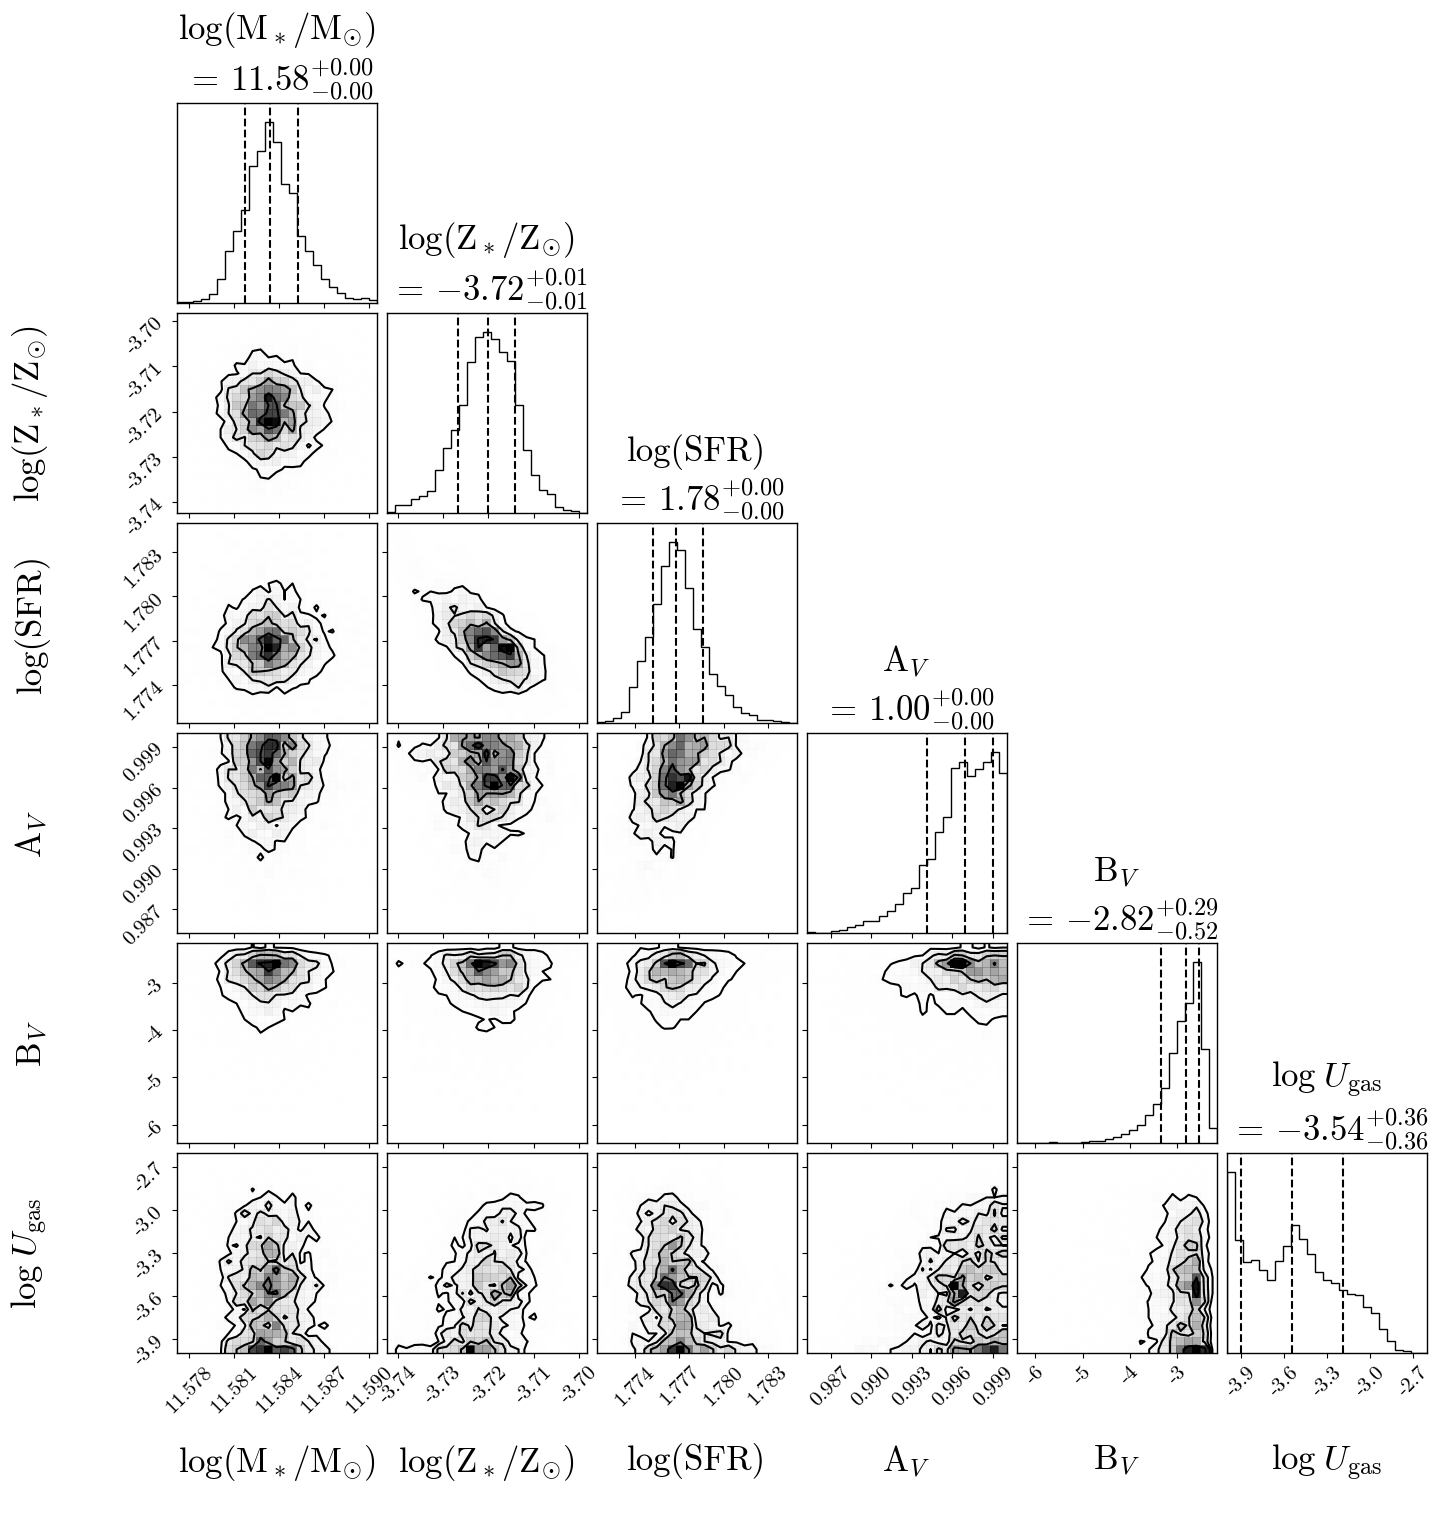

In [10]:
# model_params_names = [m.get('name') for m in model_params]
model_params_names = model.theta_labels()
model_params_names.index('logzsol')
idx = np.argsort(weights)[-5000:] 

parnames = [p['name'] for p in model.config_list]
agebins = np.array(model.config_list[parnames.index('agebins')]['init'])
print("agebins shape:", agebins.shape)  # should be (8, 2)

sfr_samples_top = model_sfr[idx, :]
dt = np.diff(10**agebins, axis=-1)[:, 0]  # bin widths in yr, shape (nbin,)
total_sfr = np.sum(sfr_samples_top * dt, axis=1) / np.sum(dt)  # shape (5000,)
log_sfr = np.log10(total_sfr)

data = {'log(M$_*$/M$_{\odot}$)\n': np.log10(stellar_masses),
       'log(Z$_*$/Z$_{\odot}$)\n': results['chain'][idx,model_params_names.index('logzsol')],
       'log(SFR)\n': log_sfr,
       'A$_V$\n': results['chain'][idx,model_params_names.index('dust2')],
       'B$_V$\n': np.log10(results['chain'][idx,model_params_names.index('duste_gamma')]),
        'log$\;U_{\mathrm{gas}}$\n': results['chain'][idx,model_params_names.index('gas_logu')],
}
        
df = pd.DataFrame(data)


figure = corner.corner(df,labels=list(data.keys()),
                       quantiles=[0.16, 0.5, 0.84],
                       show_titles=True, title_kwargs={"fontsize": 25}, label_kwargs={'fontsize': 25}, labelpad=0.15,
                      bins=25,plot_datapoints=False)


In [11]:
def get_spec_posterior(res, obs, model, sps, nsample=200, percentiles=[16, 50, 84]):
    """
    Returns the spectrum posterior in units of maggies.
    """
    theta_labels = res.get('theta_labels', model.theta_labels())
    chain = res['chain']
    weights = res.get('weights', None)
    nsamples = chain.shape[0]

    # draw representative samples using dynesty weights
    if weights is not None:
        weights_norm = weights / weights.sum()
        idx = np.random.choice(nsamples, size=nsample, replace=False, p=weights_norm)
    else:
        idx = np.random.choice(nsamples, size=nsample, replace=False)

    spec_samples = []
    for ii, i in enumerate(idx):
        theta = chain[i]
        spec, phot, mfrac = model.predict(theta, obs=obs, sps=sps)
        spec_samples.append(spec)
        if ii % 50 == 0:
            print(f'  {ii}/{nsample} done')

    spec_samples = np.array(spec_samples)  # (nsample, nwave)

    spec_lo  = np.percentile(spec_samples, percentiles[0], axis=0)
    spec_mid = np.percentile(spec_samples, percentiles[1], axis=0)
    spec_hi  = np.percentile(spec_samples, percentiles[2], axis=0)
    
    # wavelength array is stored in obs
    wavelength = obs['wavelength']  # in Angstroms, observed frame

    return wavelength, spec_lo, spec_mid, spec_hi, spec_samples


In [12]:
wavelength, spec_lo, spec_mid, spec_hi, spec_samples = get_spec_posterior(
    results, observations_dict, model, sps, nsample=200
)

  0/200 done
  50/200 done
  100/200 done
  150/200 done


In [13]:
chain = results.get('chain', None)
lnprobability = results.get('lnprobability', None)
flat_lnprobability = lnprobability.reshape(-1)
flat_chain = chain.reshape(-1, chain.shape[-1])
best_fit_index = np.argmax(flat_lnprobability)
bestfit_params = flat_chain[best_fit_index]

In [14]:
# mod_obs = observations_dict.copy()
mod_obs = {}
mod_obs['filters'] = observations_dict['filters']
mod_obs['wavelength'] = np.arange(4750,50000,2.5)
spec,phot,extras = model.predict(bestfit_params, sps=sps,obs=mod_obs)

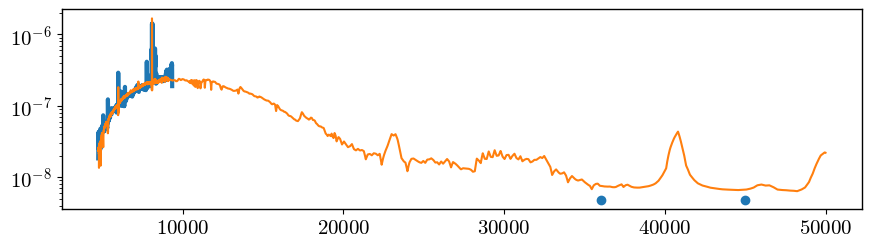

In [ ]:
fig, ax = pf.create_plot([8,2])
ax.plot(observations_dict['wavelength'],observations_dict['spectrum'], lw=3)
ax.plot(mod_obs['wavelength'],spec)
ax.scatter([36000,45000],observations_dict['maggies'])

ax.set_yscale('log')


In [30]:
def plot_sfh_step_continuous(ax, agebins, sfh_lo, sfh_hi, sfh_med):
    """
    Plots star formation history as a continuous step plot, correctly
    handling non-contiguous bins.

    This version builds the coordinate arrays for plotting and explicitly
    inserts `np.nan` where gaps between bins occur. This prevents matplotlib
    from drawing incorrect connecting lines across those gaps.

    Parameters:
    - ax: The matplotlib axes object to plot on.
    - agebins: An array of shape (N, 2) defining the age bins in Gyr.
    - sfh_lo: The lower uncertainty of the SFH for each bin.
    - sfh_hi: The upper uncertainty of the SFH for each bin.
    - sfh_med: The median SFH for each bin.
    """
    bin_lo_gyr = agebins[:, 0]
    bin_hi_gyr = agebins[:, 1]

    # Create coordinate arrays for a continuous step plot.
    # We start by creating the coordinates as if all bins were contiguous.
    # x will be [bin_lo_0, bin_hi_0, bin_lo_1, bin_hi_1, ...]
    # y will be [sfh_0,    sfh_0,    sfh_1,    sfh_1,    ...]
    x_coords = list(np.array([bin_lo_gyr, bin_hi_gyr]).T.flatten())
    y_med_coords = list(np.repeat(sfh_med, 2))
    y_lo_coords = list(np.repeat(sfh_lo, 2))
    y_hi_coords = list(np.repeat(sfh_hi, 2))

    # Now, iterate through the bins to find any gaps.
    # Where a gap exists, we insert a `NaN` to break the line plot.
    insert_offset = 0
    for i in range(agebins.shape[0] - 1):
        # Check if the end of the current bin matches the start of the next one
        if bin_hi_gyr[i] != bin_lo_gyr[i+1]:
            # If they don't match, there's a gap.
            # We need to insert a break after the points for the current bin.
            # The insertion index is after the two points of the current bin.
            insert_idx = 2 * (i + 1) + insert_offset
            
            x_coords.insert(insert_idx, np.nan)
            y_med_coords.insert(insert_idx, np.nan)
            y_lo_coords.insert(insert_idx, np.nan)
            y_hi_coords.insert(insert_idx, np.nan)
            
            # Increment the offset since we've added an element to the lists
            insert_offset += 1
    x_coords = 10**np.array(x_coords)/10**9

    # Plot the uncertainty range as a continuous filled area
    ax.fill_between(
        x_coords,
        y_lo_coords,
        y_hi_coords,
        alpha=0.3, color='#77aca2',
        label='68% Confidence Interval'
    )

    # Plot the median SFH as a continuous step line
    ax.plot(
        x_coords,
        y_med_coords,
        color='#ff004f',
        linewidth=3,
        label='Median SFH'
    )


/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_95475/1621353855.py:81: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  zred         = float(model.params['zred'])
/Users/thardy/Documents/durham/eelgs/.venv/lib/python3.13/site-packages/prospect/models/priors.py:125: RuntimeWarning: divide by zero encountered in log
  lnp = np.log(p)
/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_95475/1621353855.py:226: RuntimeWarning: invalid value encountered in subtract
  p_vals = np.exp(log_p - log_p.max())


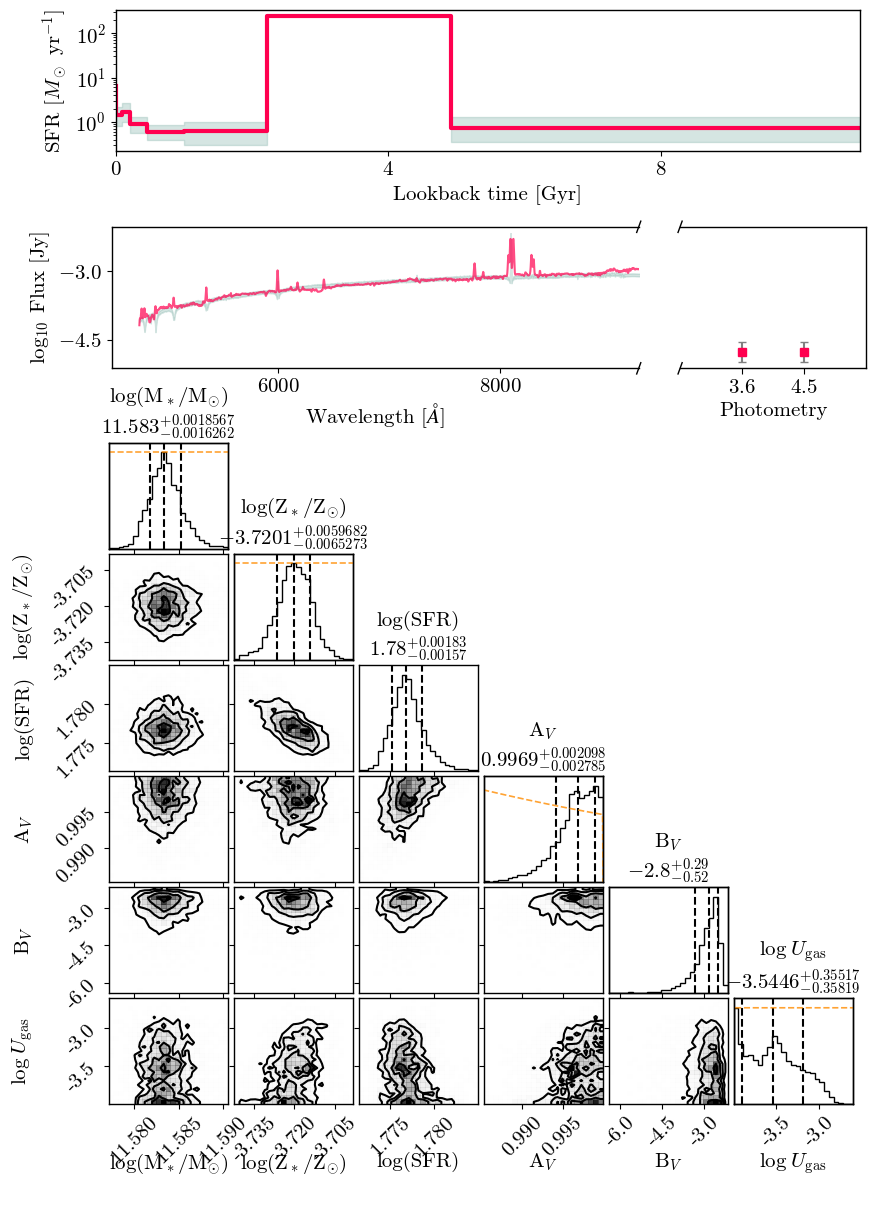

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import corner
import pandas as pd
from astropy.cosmology import Planck18 as cosmo

FONTSIZE = 15  # single source of truth for all font sizes

plt.rcParams.update({
    'font.size':        FONTSIZE,
    'axes.titlesize':   FONTSIZE,
    'axes.labelsize':   FONTSIZE,
    'xtick.labelsize':  FONTSIZE,
    'ytick.labelsize':  FONTSIZE,
    'legend.fontsize':  FONTSIZE,
})

def format_title(val, low, high, sig_figs):
    def to_sf(x, sf):
        if x == 0:
            return '0'
        from decimal import Decimal
        rounded = float(f'{x:.{sf-1}e}')
        d = Decimal(str(rounded))
        exp = d.as_tuple().exponent
        dp = max(0, -exp)
        return f'{rounded:.{dp}f}'
    return f'${to_sf(val, sig_figs)}^{{+{to_sf(high, sig_figs)}}}_{{-{to_sf(low, sig_figs)}}}$'

def add_break_markers(ax_left, ax_right, size=6, angle=70):
    """
    Draw break markers at a fixed physical size in display coordinates.
    size: length of marker in points
    angle: angle of diagonal in degrees
    """
    import matplotlib.transforms as mtransforms
    import numpy as np

    dx = size * np.cos(np.radians(angle))
    dy = size * np.sin(np.radians(angle))

    for ax, x_ax in [(ax_left, 1.0), (ax_right, 0.0)]:
        # convert axes boundary point to display coordinates
        disp = ax.transAxes.transform((x_ax, 0.5))

        for y_frac in [0.0, 1.0]:
            disp_pt = ax.transAxes.transform((x_ax, y_frac))
            # draw in display coords then convert back to axes coords
            x0_disp, y0_disp = disp_pt
            # two points of the marker in display space
            p1 = ax.transAxes.inverted().transform((x0_disp - dx, y0_disp - dy))
            p2 = ax.transAxes.inverted().transform((x0_disp + dx, y0_disp + dy))
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]],
                    transform=ax.transAxes,
                    color='k', linewidth=1, clip_on=False)

param_keys = ['logmass', 'logzsol', None, 'dust2', 'duste_gamma', 'gas_logu']
sig_figs   = [5, 5, 3, 4, 2, 5]
labels     = list(data.keys())
n_params   = len(data)
df         = pd.DataFrame(data)

# ---- figure with subfigures so corner gets a clean axes-free canvas ------
fig = plt.figure(figsize=(8.27, 11.69))
subfigs = fig.subfigures(3, 1, height_ratios=[1, 1, 4], hspace=0.09)

ax_sfh  = subfigs[0].add_subplot(1, 1, 1)
# replace the single ax_spec line with this
spec_subfigs = subfigs[1].subfigures(1, 2, width_ratios=[3, 1], wspace=0.0)
ax_spec_opt  = spec_subfigs[0].add_subplot(1, 1, 1)
ax_spec_ir   = spec_subfigs[1].add_subplot(1, 1, 1)

# share the y axis manually (subfigures can't sharey at creation time)
ax_spec_ir.sharey(ax_spec_opt)
ax_spec_ir.tick_params(labelleft=False)  # hide duplicate y tick labels on the right panel

# ---- SFH reconstruction --------------------------------------------------
agebins      = model.params['agebins']
time_per_bin = np.diff(10**agebins, axis=-1)[:, 0]
zred         = float(model.params['zred'])
tuniv_gyr    = cosmo.age(zred).value

n_draw      = min(200, len(idx))
sfh_samples = []

for i in np.random.choice(idx, size=n_draw, replace=False):
    logmass        = results['chain'][i, model_params_names.index('logmass')]
    sfr_ratio_idxs = [k for k, l in enumerate(model_params_names) if l.startswith('logsfr_ratios')]
    logsfr_ratios  = results['chain'][i, sfr_ratio_idxs]
    masses         = logsfr_ratios_to_masses(
        logmass=logmass, logsfr_ratios=logsfr_ratios, agebins=agebins,
    )
    sfh_samples.append(masses / time_per_bin)

sfh_samples = np.array(sfh_samples)
sfh_lo  = np.percentile(sfh_samples, 16, axis=0)
sfh_med = np.percentile(sfh_samples, 50, axis=0)
sfh_hi  = np.percentile(sfh_samples, 84, axis=0)

bin_lo_gyr = 10**agebins[:, 0] / 1e9
bin_hi_gyr = 10**agebins[:, 1] / 1e9

# for k in range(agebins.shape[0]):
#     ax_sfh.fill_between(
#         [bin_lo_gyr[k], bin_hi_gyr[k]],
#         [sfh_lo[k],     sfh_lo[k]],
#         [sfh_hi[k],     sfh_hi[k]],
#         alpha=0.3, color='#77aca2',
#     )
#     ax_sfh.step(
#         [bin_lo_gyr[k], bin_hi_gyr[k]],
#         [sfh_med[k],    sfh_med[k]],
#         color='#ff004f', linewidth=3, where='post',
#     )

# ax_sfh.set_xscale('log')

plot_sfh_step_continuous(ax_sfh,agebins,sfh_lo,sfh_hi,sfh_med)

ax_sfh.set_xlim(0, tuniv_gyr)
ax_sfh.set_yscale('log')
ax_sfh.set_xlabel('Lookback time [Gyr]')
ax_sfh.set_ylabel('SFR [$M_\odot$ yr$^{-1}$]')
ax_sfh.xaxis.set_major_locator(plt.MaxNLocator(3))
ax_sfh.yaxis.set_major_locator(plt.LogLocator(numticks=3))


# =========================================================================
# Spectrum panel — optical
# =========================================================================
ax_spec_opt.set_xlim(4500, 9250)
ax_spec_opt.set_xlabel(r'Wavelength $[\AA]$')
ax_spec_opt.set_ylabel(r'$\log_{10}\;$Flux [Jy]')
ax_spec_ir.set_xlabel('Wavelength $[\mu $m$]$')
ax_spec_opt.xaxis.set_major_locator(plt.MaxNLocator(3))
ax_spec_ir.xaxis.set_major_locator(plt.MaxNLocator(3))
ax_spec_opt.yaxis.set_major_locator(plt.MaxNLocator(3))
ax_spec_opt.tick_params(labelsize=FONTSIZE)
ax_spec_opt.spines['right'].set_visible(False)
ax_spec_opt.tick_params(right=False)


# =========================================================================
# Spectrum panel — IR photometry
# =========================================================================
irac_x      = [1, 2]
irac_labels = [r'$3.6$', r'$4.5$']

ax_spec_ir.set_xlim(0, 3)
ax_spec_ir.set_xticks(irac_x)
ax_spec_ir.set_xticklabels(irac_labels)
ax_spec_ir.xaxis.set_tick_params(length=4)
ax_spec_ir.yaxis.set_major_locator(plt.MaxNLocator(3))
ax_spec_ir.tick_params(left=False, labelleft=False)
ax_spec_ir.spines['left'].set_visible(False)
ax_spec_ir.set_xlabel('Photometry')


# -- plug your data in here -----------------------------------------------
ax_spec_opt.plot(observations_dict['wavelength'], np.log10(observations_dict['spectrum']*3631),
                 color='#ff004f', linewidth=1.5, alpha=0.7, zorder=10)
ax_spec_opt.fill_between(observations_dict['wavelength'], 0.99*np.log10(spec_lo*3631), 1.01*np.log10(spec_hi*3631),
                          alpha=0.3, color='#77aca2')
ax_spec_ir.errorbar(irac_x, np.log10(observations_dict['maggies']*3631),
                    yerr=0.432*observations_dict['maggies_unc']*5/observations_dict['maggies'],
                    fmt='s', color='#ff004f', capsize=3, ecolor='gray')
# ax_spec_ir.scatter(irac_x, phot_med, color='darkorange', zorder=5, s=20)

# ---- align SFH and spec left edges with the corner plot -----------------
# corner uses ~13% of figure width for its left margin at n_params=6
# we replicate that by setting the left spine position after drawing corner,
# or more reliably, by tightening the subfig left padding to match corner's
subfigs[0].subplots_adjust(left=0.08, right=0.98)
spec_subfigs[0].subplots_adjust(left=0.1, right=0.95)
spec_subfigs[1].subplots_adjust(left=0.05, right=0.95)

add_break_markers(ax_spec_opt, ax_spec_ir)

# ---- corner plot ---------------------------------------------------------
corner.corner(
    df,
    labels=labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": FONTSIZE},
    label_kwargs={"fontsize": FONTSIZE},
    labelpad=0.15,
    bins=25,
    plot_datapoints=False,
    fig=subfigs[2],
    color='k'
)

corner_axes = np.array(subfigs[2].axes).reshape((n_params, n_params))

# force all corner tick and title font sizes to match
for ax in subfigs[2].axes:
    ax.tick_params(labelsize=FONTSIZE)
    if ax.get_title():
        ax.title.set_fontsize(FONTSIZE)
    ax.xaxis.label.set_fontsize(FONTSIZE)
    ax.yaxis.label.set_fontsize(FONTSIZE)

# ---- per-axis customisation: titles and prior overlays ------------------
for i in range(n_params):
    ax_diag  = corner_axes[i, i]
    samples  = df.iloc[:, i].values
    q16, q50, q84 = np.percentile(samples, [16, 50, 84])
    title_str = format_title(q50, q50 - q16, q84 - q50, sig_figs[i])
    ax_diag.set_title(
        f'{labels[i].strip()}\n{title_str}',
        fontsize=FONTSIZE, pad=3,
    )

    key = param_keys[i]
    if key is not None:
        try:
            param_cfg = next(p for p in model.config_list if p['name'] == key)
            prior_obj = param_cfg.get('prior', None)
            if prior_obj is not None:
                pad_frac = 0.15 * (samples.max() - samples.min())
                x_prior  = np.linspace(samples.min() - pad_frac,
                                       samples.max() + pad_frac, 300)
                log_p  = prior_obj(x_prior)
                p_vals = np.exp(log_p - log_p.max())
                hist_vals, _ = np.histogram(samples, bins=25)
                scale    = hist_vals.max()
                ax_twin  = ax_diag.twinx()
                ax_twin.plot(x_prior, p_vals * scale,
                             color='darkorange', linewidth=1.2,
                             linestyle='--', alpha=0.8)
                ax_twin.set_ylim(0, scale * 1.1)
                ax_twin.set_yticks([])
        except (StopIteration, Exception):
            pass

    ax_diag.xaxis.set_major_locator(plt.MaxNLocator(3))

for i in range(n_params):
    for j in range(i):
        corner_axes[i, j].xaxis.set_major_locator(plt.MaxNLocator(3))
        corner_axes[i, j].yaxis.set_major_locator(plt.MaxNLocator(3))

plt.savefig('corner_a4.pdf', bbox_inches='tight', dpi=300,
            facecolor='white', format='pdf')
plt.show()

In [17]:
model_params_names

['logmass',
 'logsfr_ratios_1',
 'logsfr_ratios_2',
 'logsfr_ratios_3',
 'logsfr_ratios_4',
 'logsfr_ratios_5',
 'logsfr_ratios_6',
 'logsfr_ratios_7',
 'dust2',
 'logzsol',
 'dust_index',
 'dust1_fraction',
 'duste_qpah',
 'duste_gamma',
 'duste_umin',
 'gas_logu']

In [18]:
model.params['logzsol']

array([-3.71124554])

In [19]:
results['chain']

array([[ 1.26306151e+01,  3.62708213e-01,  1.57789330e+00, ...,
         5.49360964e-01,  2.34503126e+01,  6.53576911e-01],
       [ 1.24313875e+01,  7.75392264e-02,  3.32788230e-01, ...,
         7.85587945e-01,  1.24141034e+00,  2.29571668e+00],
       [ 1.14703574e+01,  1.87948810e+00,  2.29738907e-01, ...,
         6.04650122e-01,  3.55135656e+00,  1.82250324e+00],
       ...,
       [ 1.18146231e+01,  3.07021969e-01,  2.78216263e-01, ...,
         2.05878563e-04,  1.99591283e+01, -3.98249469e+00],
       [ 1.18156485e+01,  4.33329828e-01,  6.21078733e-01, ...,
         2.03430226e-04,  2.49432030e+01, -3.90828117e+00],
       [ 1.18157937e+01,  4.44562227e-01,  6.06075419e-01, ...,
         2.41200851e-04,  2.47793555e+01, -3.91128346e+00]],
      shape=(39930, 16))

In [28]:
agebins

array([[ 0.        ,  7.        ],
       [ 7.        ,  8.        ],
       [ 8.        ,  8.33333333],
       [ 8.33333333,  8.66666667],
       [ 8.66666667,  9.        ],
       [ 9.        ,  9.34608957],
       [ 9.34608957,  9.69217914],
       [ 9.69217914, 10.0382687 ]])